In [198]:
ML_DATA_TRAIN_PATH = './../data/final_data/ml_final_data_train.csv'
ML_DATA_VAL_PATH = './../data/final_data/ml_final_data_val.csv'
ML_DATA_TEST_PATH = './../data/final_data/ml_final_data_test.csv'
MODEL_PATH = './../stored_models/model_2_underfitting.h5'
import sqlite3
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.python.client import device_lib
import os
import sys
from collections import Counter
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input, BatchNormalization, Activation, Add
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras import layers
from tensorflow.keras.applications import InceptionResNetV2, VGG16, MobileNetV2
from tensorflow.keras.utils import to_categorical
from PIL import Image
import requests
import zipfile

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output as cls
from keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
import pandas as pd
import PIL

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import statistics
import ast
import json

import glob
import cv2
from PIL import Image
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

In [6]:
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, file_path, read_size, batch_size, num_classes, csv_length):
        self.file_path = file_path
        self.batch_size = batch_size
        self.read_size = read_size
        self.num_classes = num_classes
        self.csv_length = csv_length
        self.current_read = None
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(self.csv_length / self.batch_size))

    def on_epoch_end(self):
        pass

    def __getitem__(self, index):
        if index % (self.read_size // self.batch_size) == 0:
            self.current_read = pd.read_csv(self.file_path, skiprows=range(1, (index * self.batch_size) + 1), nrows=self.read_size)
        batch = self.get_batch(index % (self.read_size // self.batch_size))
        X, y = self.__data_generation__(batch)
        return X, y

    def __data_generation__(self, df):
        X = np.array(df['board'].apply(json.loads).tolist())
        y = self.encode_pos(df['initial_pos'])
        return X, y
    
    def get_batch(self, index):
        start = index * self.batch_size
        end = start + self.batch_size
        return self.current_read.iloc[start:end]

    def encode_pos(self, positions):
        column_to_number = {
            'a': 1,
            'b': 2,
            'c': 3,
            'd': 4,
            'e': 5,
            'f': 6,
            'g': 7,
            'h': 8
        }
        encoded_positions = []
        for pos in positions:
            encoded_pos = np.zeros(64)
            encoded_pos[((column_to_number.get(pos[0]) - 1)) +  ((8 - int(pos[1])) * 8)] = 1
            encoded_positions.append(encoded_pos)
        return np.array(encoded_positions)

In [17]:
def bar_plot(x, y):
    plt.figure(figsize=(15, 6))
    plt.bar(x, y)
    plt.title('Moves predicted')
    plt.xlabel('Move')
    plt.ylabel('Count')
    plt.xticks(x, [f'{i}' for i in x])
    plt.tight_layout()
    plt.show()

In [182]:
def two_bar_plot(x, y1, y2):
    bar_width = 0.35
    indices = np.arange(len(x))
    plt.figure(figsize=(15, 6))
    plt.bar(indices, y1, bar_width, label='Predicted')
    plt.bar(indices + bar_width, y2, bar_width, label='Ground Truth')
    plt.xlabel('Categories')
    plt.ylabel('Values')
    plt.title('Bar Plot with Two Sets of Bars')
    plt.xticks(indices + bar_width / 2, x)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [8]:
model = load_model(MODEL_PATH)

In [9]:
read_size = 524288
batch_size = 64
num_classes = 64
test_data_generator = DataGenerator(ML_DATA_TEST_PATH, read_size, batch_size, num_classes, 482813)

In [7]:
model.evaluate(test_data_generator)
test_data_generator.current_read = None


7544/7544 [==============================] - 65s 7ms/step - loss: 1.4311 - accuracy: 0.5058


[1.4311156272888184, 0.5057734847068787]

In [10]:
predictions = model.predict(test_data_generator)
test_data_generator.current_read = None

7544/7544 [==============================] - 59s 6ms/step


In [11]:
predictions = np.argmax(predictions,axis=1)

In [12]:
predictions

array([30, 28, 42, ..., 58, 60, 29], dtype=int64)

In [13]:
group_predictions = np.unique(predictions, return_counts=True)

In [88]:
def decode_pos(positions):
        number_to_column = {
            1 : 'a',
            2 : 'b',
            3 : 'c',
            4 : 'd',
            5 : 'e',
            6 : 'f',
            7 : 'g',
            8 : 'h'
        }
        decoded_positions = []
        for pos in positions:
            decoded_pos = number_to_column.get(pos % 8 + 1) + str(8 - (pos // 8))
            decoded_positions.append(decoded_pos)
        return np.array(decoded_positions)

In [92]:
group_predictions_labels = decode_pos(group_predictions[0])

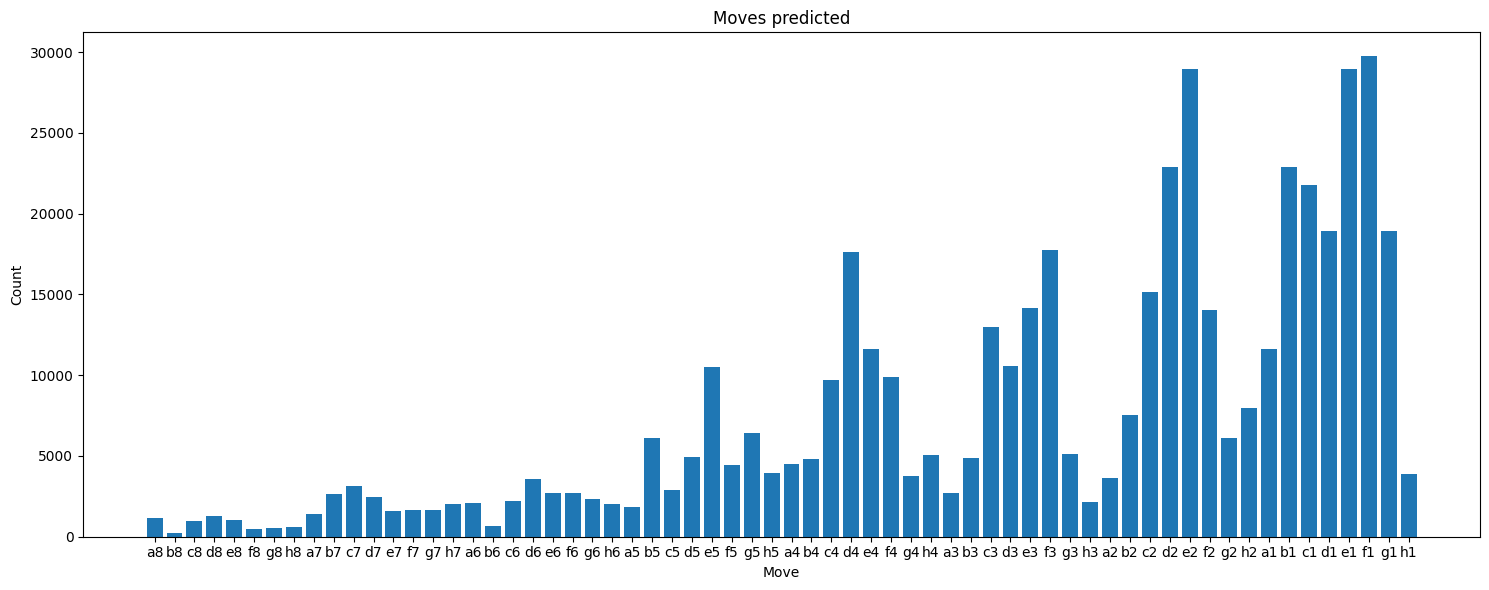

In [99]:
bar_plot(decode_pos(group_predictions[0]), group_predictions[1])

In [90]:
test_df = pd.read_csv(ML_DATA_TEST_PATH)

In [169]:
def sort_value_counts(value_counts):
    sorted_value_counts = []
    for row in ['8','7','6','5','4','3','2','1']:
        for column in ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']:
            sorted_value_counts.append(value_counts[column + row])
    return sorted_value_counts

In [170]:
sorted_value_counts = sort_value_counts(test_df['initial_pos'].value_counts())

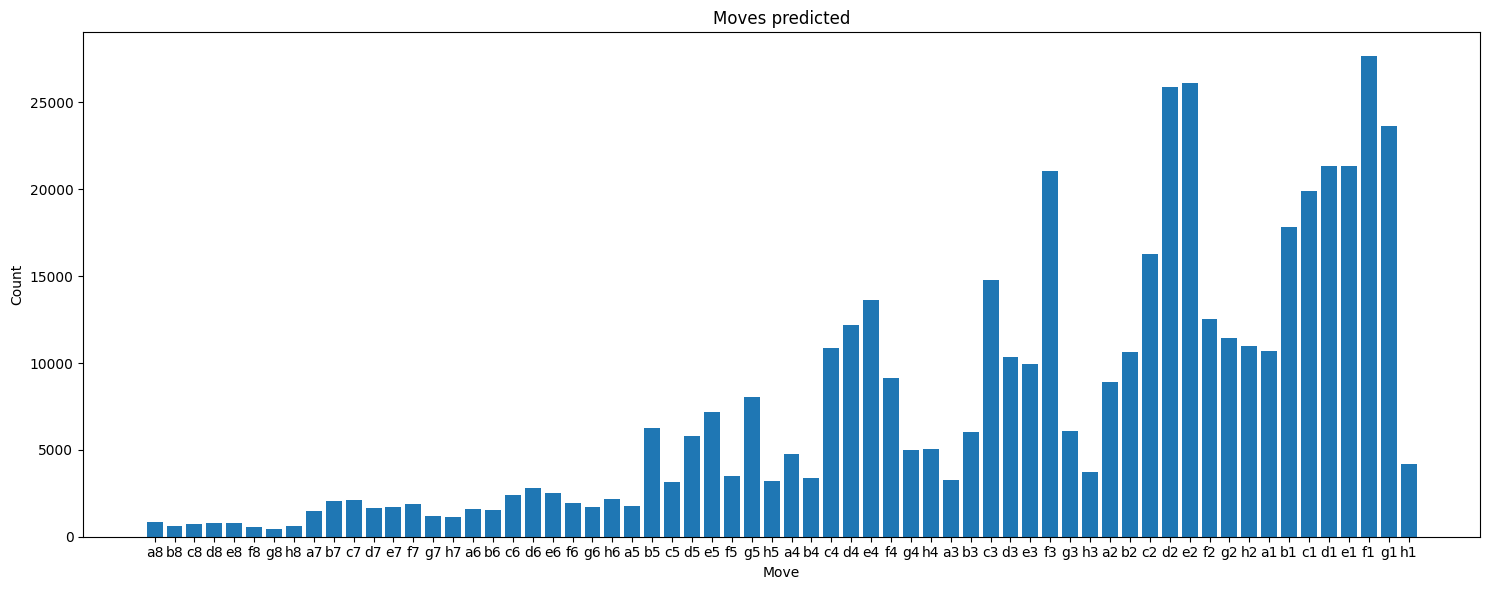

In [211]:
bar_plot(decode_pos(group_predictions[0]), sorted_value_counts)

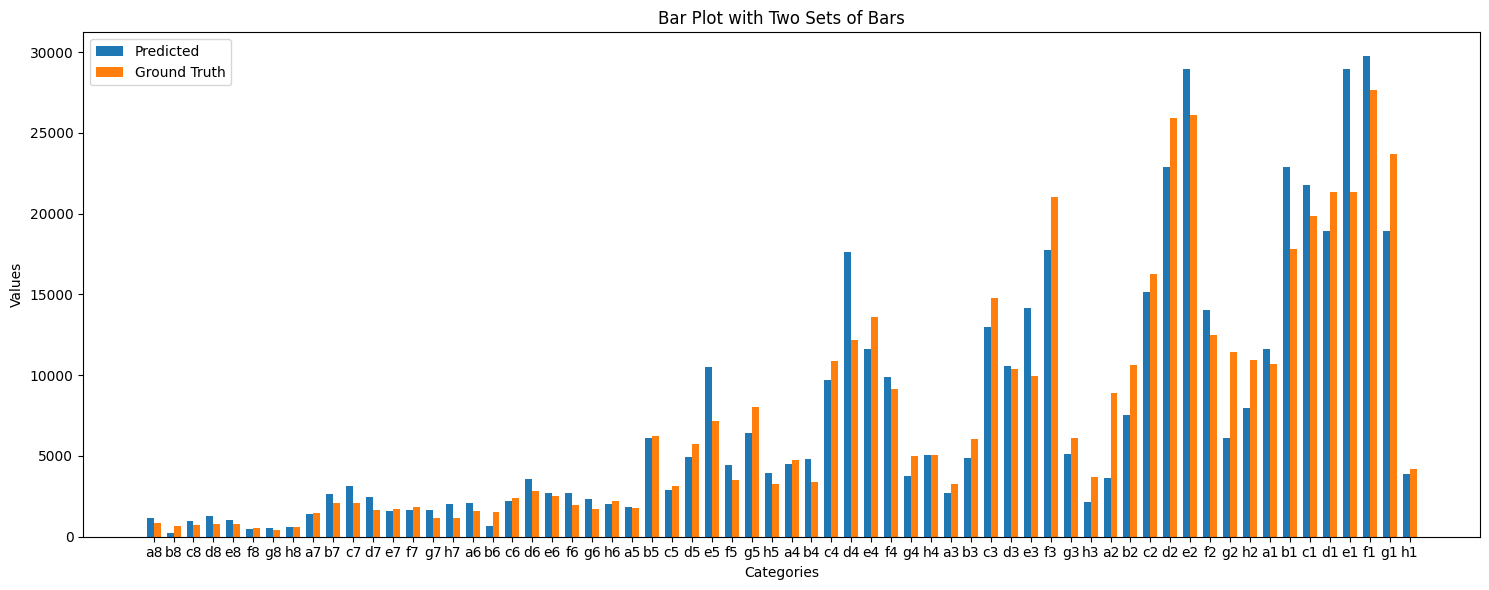

In [183]:
two_bar_plot(decode_pos(group_predictions[0]), group_predictions[1], sorted_value_counts)

In [154]:
print(classification_report(test_df['initial_pos'], decode_pos(predictions)))

              precision    recall  f1-score   support

          a1       0.38      0.41      0.40     10683
          a2       0.45      0.18      0.26      8905
          a3       0.49      0.40      0.44      3274
          a4       0.57      0.54      0.55      4746
          a5       0.52      0.53      0.53      1781
          a6       0.49      0.65      0.56      1570
          a7       0.54      0.51      0.52      1492
          a8       0.50      0.68      0.57       849
          b1       0.45      0.57      0.50     17825
          b2       0.49      0.35      0.41     10611
          b3       0.53      0.43      0.48      6026
          b4       0.43      0.61      0.50      3380
          b5       0.64      0.63      0.64      6259
          b6       0.67      0.29      0.41      1521
          b7       0.52      0.66      0.58      2080
          b8       0.76      0.29      0.42       634
          c1       0.43      0.47      0.45     19889
          c2       0.48    

In [196]:
f1_scores = f1_score(test_df['initial_pos'], decode_pos(predictions), average=None)

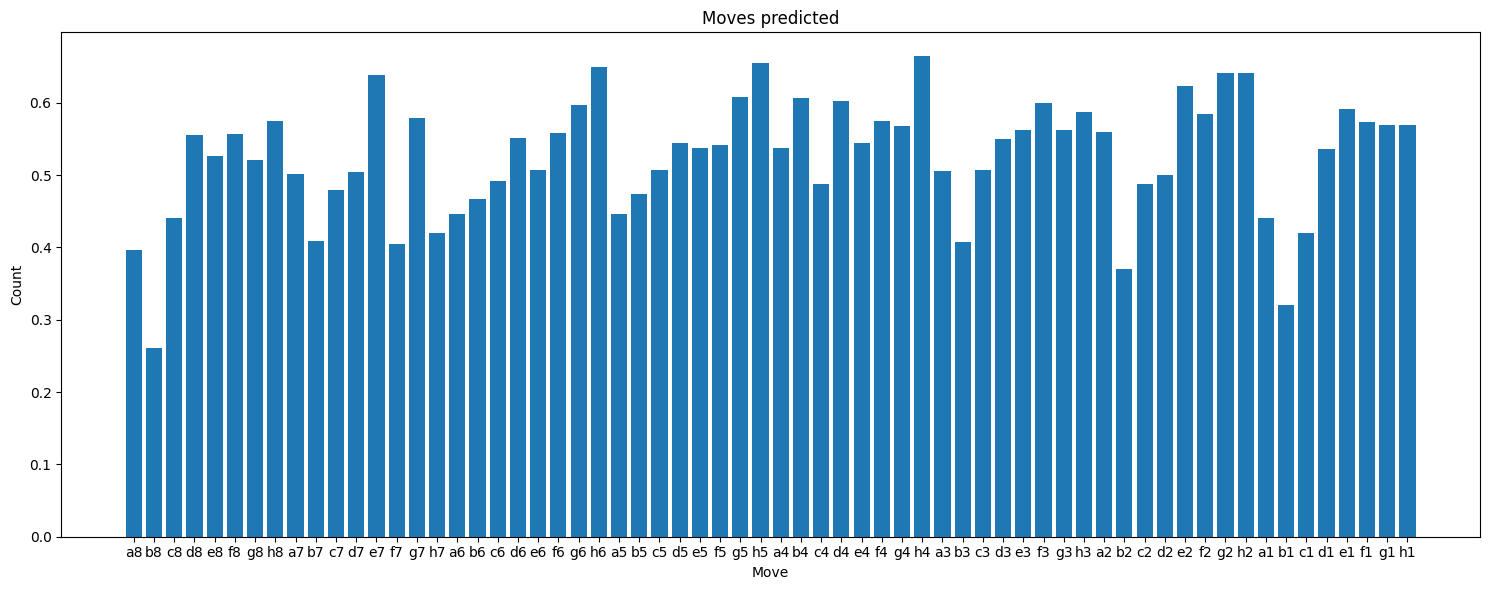

In [197]:
bar_plot(decode_pos(group_predictions[0]), f1_scores)

In [207]:
matrix = confusion_matrix(test_df['initial_pos'], decode_pos(predictions))
accuracy_scores = matrix.diagonal()/matrix.sum(axis=1)

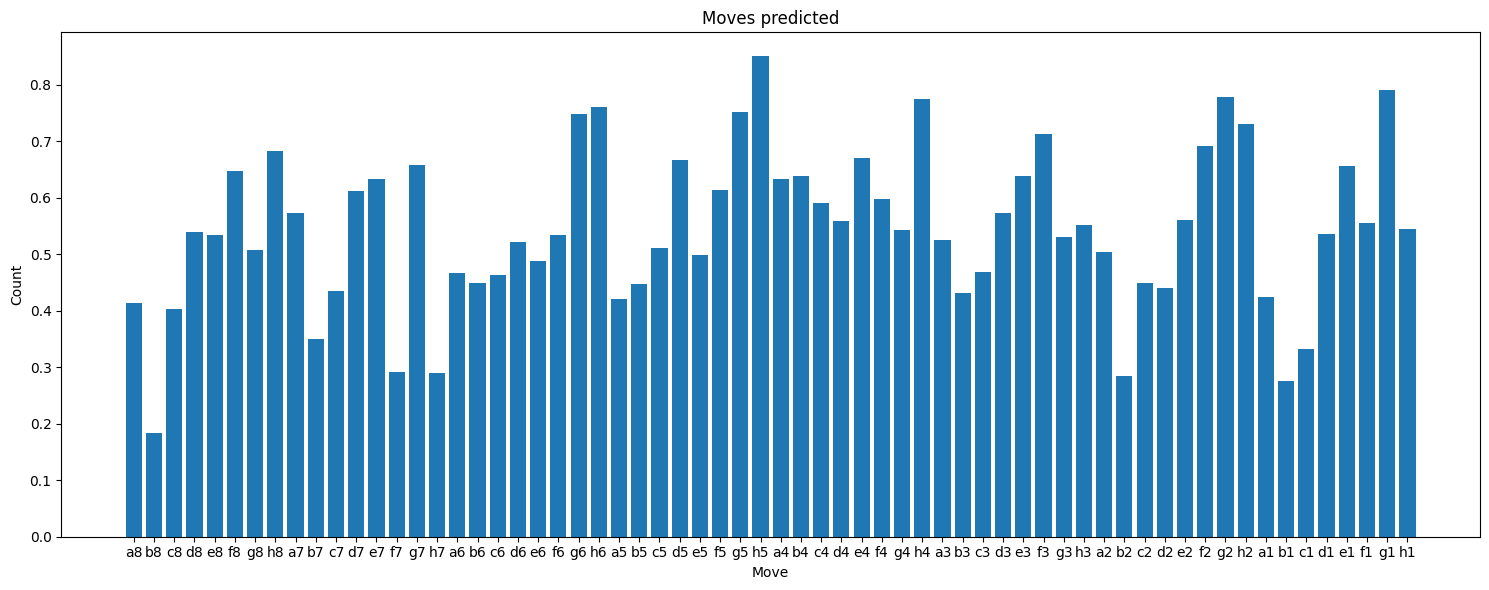

In [210]:
bar_plot(decode_pos(group_predictions[0]), accuracy_scores)

In [199]:
class_weights = compute_class_weight('balanced', classes=np.unique(test_df['initial_pos']), y=test_df['initial_pos'])

In [200]:
class_weights

array([ 0.70616429,  0.84715925,  2.30420071,  1.58953922,  4.23579625,
        4.80506568,  5.05626885,  8.88569273,  0.42322318,  0.71095591,
        1.25190062,  2.23193879,  1.20529687,  4.95986399,  3.62690054,
       11.89897969,  0.37930279,  0.46310332,  0.51141978,  0.69350553,
        2.41483775,  3.11090851,  3.58723401, 10.65530102,  0.35301606,
        0.29129482,  0.72740846,  0.61977926,  1.30721766,  2.67042588,
        4.53362568,  9.26775568,  0.35306562,  0.2887306 ,  0.75727295,
        0.55421342,  1.04981257,  3.0260542 ,  4.41942187,  9.90020095,
        0.27278804,  0.6026003 ,  0.35845069,  0.82691583,  2.14866224,
        3.83525832,  4.0624411 , 13.28160761,  0.31865984,  0.66036004,
        1.23367999,  1.51667735,  0.94075984,  4.43501066,  6.42038564,
       17.18440347,  1.79832017,  0.68812853,  2.02685468,  1.49148935,
        2.33197933,  3.44158445,  6.60013397, 11.93663469])

In [202]:
class_weights_dict = {cls: weight for cls, weight in zip(np.unique(test_df['initial_pos']), class_weights)}

In [204]:
with open('./../utils/initial_pos_weights.json', 'w') as f:
    json.dump(class_weights_dict, f)